# Data Collection

> Collect rollouts/episodes from the FindGoal env and save them to disk for later use in training and evaluation.

In [ ]:
#| default_exp data.collect

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
from fastcore import *
from fastcore.utils import *

In [6]:
#| hide
import numpy as np
rollouts = [np.load(f'./exp/data/rollouts/rollout_{i}.npz', allow_pickle=True) for i in range(10)]
list(rollouts[0].keys())

['episode_len',
 'success',
 'success_at',
 'seed',
 'policy',
 'layout',
 'goal_obs',
 'goal_pos',
 '0_img',
 '0_pov',
 '0_pos',
 '0_dir',
 '0_act',
 '0_rew',
 '0_csi',
 '1_img',
 '1_pov',
 '1_pos',
 '1_dir',
 '1_act',
 '1_rew',
 '1_csi']

In [17]:
[rollouts[i]['success'] for i in range(10) if 'success' in rollouts[i].keys()]

[array(True),
 array(True),
 array(True),
 array(False),
 array(True),
 array(True),
 array(True),
 array(True),
 array(True),
 array(True)]

In [20]:
[rollouts[i]['episode_len'] for i in range(10)]

[array(40),
 array(102),
 array(90),
 array(150),
 array(37),
 array(42),
 array(30),
 array(38),
 array(55),
 array(42)]

In [18]:
sum([rollouts[i]['episode_len'] for i in range(10)]) / 10

np.float64(62.6)

In [9]:
[rollouts[i]['policy'] for i in range(10)]

[array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('random', dtype='<U6'),
 array('waypoint', dtype='<U8'),
 array('waypoint', dtype='<U8'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('epsilon_astar', dtype='<U13'),
 array('waypoint', dtype='<U8')]

In [11]:
rollouts[0]['1_csi'][:]

array([[[ 0.98043704-0.19683282j]],

       [[ 0.99514061-0.09846374j]],

       [[ 0.90712327-0.42086506j]],

       [[-0.71419579-0.69994605j]],

       [[ 0.72450042+0.68927443j]],

       [[ 0.54764181-0.8367129j ]],

       [[ 0.9950037 -0.09983797j]],

       [[ 0.9950037 -0.09983797j]],

       [[-0.92413652-0.38206249j]],

       [[ 0.77102321-0.63680696j]],

       [[ 0.77102321-0.63680696j]],

       [[ 0.97128445+0.2379213j ]],

       [[ 0.80352765-0.59526753j]],

       [[ 0.80352765-0.59526753j]],

       [[ 0.69777846-0.7163136j ]],

       [[-0.8443259 -0.53583002j]],

       [[ 0.97612661-0.21720204j]],

       [[ 0.93692911-0.34951955j]],

       [[ 0.9568817 +0.29047775j]],

       [[ 0.90051234+0.43483049j]],

       [[-0.54057091-0.84129852j]],

       [[ 0.74396807+0.66821516j]],

       [[ 0.74396807+0.66821516j]],

       [[ 0.26302683-0.9647885j ]],

       [[ 0.26302683-0.9647885j ]],

       [[ 0.26302683-0.9647885j ]],

       [[-0.09213236+0.99574673j]],

 

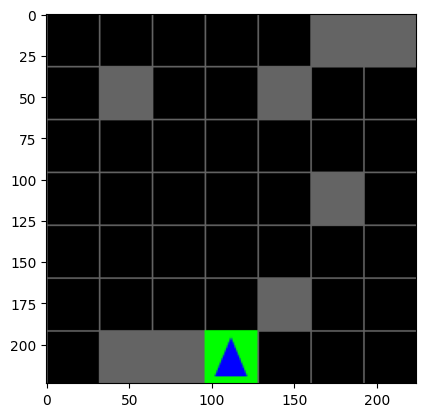

In [19]:
import matplotlib.pyplot as plt
plt.imshow(rollouts[9]['1_pov'][-1])
plt.show()

In [21]:
import h5py
file = "./exp/data/dataset.h5"
f = h5py.File(file, 'r')

In [22]:
list(f.keys())

['rollout_0',
 'rollout_1',
 'rollout_2',
 'rollout_3',
 'rollout_4',
 'rollout_5',
 'rollout_6',
 'rollout_7',
 'rollout_8',
 'rollout_9']

In [23]:
list(f['rollout_0'].attrs)

['episode_len', 'policy', 'seed', 'success', 'success_at']

In [33]:
f['rollout_0'].attrs['success_at']

np.int64(39)

In [30]:
rollout= f['rollout_0']
list(rollout.keys())

['0_act',
 '0_dir',
 '0_img',
 '0_pos',
 '0_pov',
 '0_rew',
 '1_act',
 '1_dir',
 '1_img',
 '1_pos',
 '1_pov',
 '1_rew',
 'goal_obs',
 'goal_pos',
 'layout']

In [38]:
actions = f['rollout_0/0_act']
actions.shape

(44,)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()